SEQUENTIAL GRAPHS

#Create multiple nodes that sequentially process and update different parts of the state
#Connect nodes together in a graph
#Invoke graph to see how the state is transformed step by step

In [22]:
from typing import TypedDict
from langgraph.graph import StateGraph


In [23]:
class AgentState(TypedDict):
    name: str
    yob: int
    answer:str

In [24]:
def first_node(state: AgentState)->AgentState:
    """First node of sequential graph"""
    return {
        **state,
        "answer": f"Hello {state['name']}! "
    }

In [25]:
from datetime import date

def second_node(state: AgentState)->AgentState:
    """Calculate age"""
    current_year=date.today().year
    return{
        **state,
        "answer":state["answer"]+

        f"Your age is {current_year-state['yob']}"
    }
    

In [26]:
graph=StateGraph(AgentState)
graph.add_node("NameNode",first_node)
graph.add_node("AgeNode",second_node)

graph.set_entry_point("NameNode")
graph.add_edge("NameNode","AgeNode")
graph.set_finish_point("AgeNode")

app=graph.compile()


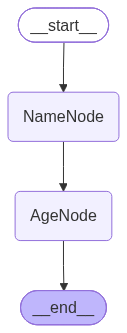

In [27]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [28]:
result=app.invoke({"name":"Guru","yob":2007})
print(result)

{'name': 'Guru', 'yob': 2007, 'answer': 'Hello Guru! Your age is 19'}


NEXT TASK

First node: Personalises name field with greeting
Second Node: Claculates age
Third Node: Lists the user's skills in a formatted string

In [29]:
from typing import TypedDict,List
from langgraph.graph import StateGraph
from datetime import date
class AgentState(TypedDict):
    name: str
    yob: int
    skills: List[str]
    answer: str

In [30]:
def node1(state:AgentState)->AgentState:
    """Greet User"""
    return{
        **state,
        "answer": f"Hello {state['name']}! Glad to see you!"
    }

def node2(state:AgentState)->AgentState:
    """Calculate Age"""
    current_year=date.today().year
    return{
        **state,
        "answer": state['answer']+f"Your age is {current_year-state['yob']}"
    }

def node3(state:AgentState)->AgentState:
    """List skills"""
    skills_str=",".join([str(skill) for skill in state['skills']])
    return{
        **state,
        "answer":state['answer']+f" You have skills in {skills_str}"
    }
    


In [31]:
graph=StateGraph(AgentState)
graph.add_node("NameNode",node1)
graph.add_node("AgeNode",node2)
graph.add_node("SkillNode",node3)

graph.set_entry_point("NameNode")
graph.add_edge("NameNode","AgeNode")
graph.add_edge("AgeNode","SkillNode")
graph.set_finish_point("SkillNode")

app=graph.compile()

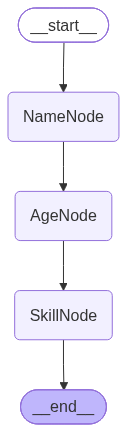

In [32]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [33]:
result=app.invoke({"name":"Raja","yob":2007,"skills":["ML","Python","Java"]})
print(result)

{'name': 'Raja', 'yob': 2007, 'skills': ['ML', 'Python', 'Java'], 'answer': 'Hello Raja! Glad to see you!Your age is 19 You have skills in ML,Python,Java'}


CONDITIONAL GRAPH

*Use start and end nodes to manage entry and exit points explicitly
*Design multiple nodes to perform diff operations
*Create a router node to handle decision making

In [34]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

In [35]:
class AgentState(TypedDict):
    n1:int
    operation:str
    n2:int
    ans:int

In [36]:
def addition(state:AgentState)->AgentState:
    """"Adds 2 numbers"""
    state['ans']=state['n1']+state['n2']
    return state

def subtraction(state:AgentState)->AgentState:
    """Subtracts 2 numbers"""
    state['ans']=state['n1']-state['n2']
    return state

def multiply(state:AgentState)->AgentState:
    """Multiply 2 numbers"""
    state['ans']=state['n1']*state['n2']
    return state

#router decides the operation
def decide_next_node(state:AgentState)->str:
    """Decides the next node of the graph"""
    if state['operation']=="+":
        return "addition_edge"
    elif state['operation']=="-":
        return "subtraction_edge"
    elif state['operation']=="*":
        return "multiplication_edge"



In [37]:
graph=StateGraph(AgentState)

graph.add_node("add_node",addition)
graph.add_node("subtract_node",subtraction)
graph.add_node("multiply_node",multiply)

graph.add_node("router",lambda state:state) #means the input state is the output state (passthrough function)

graph.add_edge(START,"router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        #edge:node
        "addition_edge":"add_node",
        "subtraction_edge":"subtract_node",
        "multiplication_edge":"multiply_node"
    }
)


graph.add_edge("add_node",END)
graph.add_edge("subtract_node",END)
graph.add_edge("multiply_node",END)

app=graph.compile()



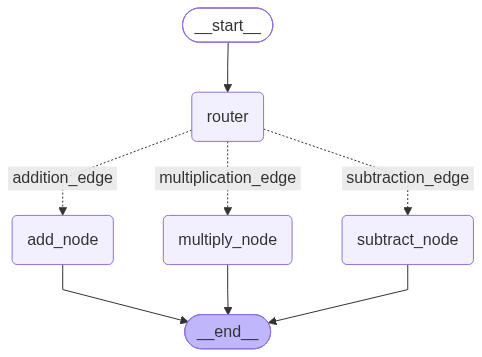

In [38]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [39]:
initial_state=AgentState(n1=10,operation='+',n2=7)
print(app.invoke(initial_state)) 

{'n1': 10, 'operation': '+', 'n2': 7, 'ans': 17}


TASK:

Make graph with 2 conditional edges

In [40]:
from typing import TypedDict,NotRequired
from langgraph.graph import StateGraph,START,END

class AgentState(TypedDict):
    n1:int
    n2:int
    op1:str
    ans1:NotRequired[int]
    n3:int
    n4:int
    op2:str
    ans2:NotRequired[int]

In [41]:
def addition_fn(state:AgentState)->AgentState:
    state['ans1']=state['n1']+state['n2']
    return state

def subtract_fn(state:AgentState)->AgentState:
    state['ans1']=state['n1']-state['n2']
    return state

def route_fn(state:AgentState)->str:
    if state['op1']=='+':
        return 'add_edge1'
    elif state['op1']=='-':
        return 'sub_edge1'



def addition_fn2(state:AgentState)->AgentState:
    state['ans2']=state['n3']+state['n4']
    return state

def subtract_fn2(state:AgentState)->AgentState:
    state['ans2']=state['n3']-state['n4']
    return state

def route_fn2(state:AgentState)->str:
    if state['op2']=='+':
        return 'add_edge2'
    elif state['op2']=='-':
        return 'sub_edge2'




In [42]:
graph=StateGraph(AgentState)

graph.add_node("add_node1",addition_fn)
graph.add_node("subtract_node1",subtract_fn)
graph.add_node("router1",lambda state:state)
graph.add_edge(START,"router1")

graph.add_node("add_node2",addition_fn2)
graph.add_node("subtract_node2",subtract_fn2)
graph.add_node("router2",lambda state:state)



graph.add_conditional_edges(
    "router1",
    route_fn,
    {
        'add_edge1':'add_node1',
        'sub_edge1':'subtract_node1'
    }
)
graph.add_conditional_edges(
    "router2",
    route_fn2,
    {
        'add_edge2':'add_node2',
        'sub_edge2':'subtract_node2'
    }
)


graph.add_edge("add_node1","router2")
graph.add_edge("subtract_node1","router2")
graph.add_edge("add_node2",END)
graph.add_edge("subtract_node2",END)


app=graph.compile()


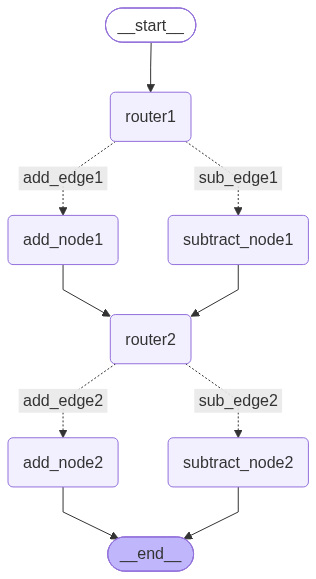

In [43]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [44]:
initial_state=AgentState(n1=10,n2=7,op1="-",n3=9,n4=6,op2="+")
print(app.invoke(initial_state))

{'n1': 10, 'n2': 7, 'op1': '-', 'ans1': 3, 'n3': 9, 'n4': 6, 'op2': '+', 'ans2': 15}


LOOPING GRAPH

-Implement looping logic to route the flow of data back to the nodes
-Create a single conditional edge to handle decision making and control graph flow

In [2]:
from typing import TypedDict,Dict,List
from langgraph.graph import StateGraph,START,END
import random

In [3]:
class AgentState(TypedDict):
    name:str
    numbers:List[int]
    counter:int

In [12]:
def greeting_fn(state:AgentState)->AgentState:
    """Greet user"""
    state['name']=f"Hello {state['name']}! Have a great day!"
    state['counter']=0
    return state

def random_fn(state:AgentState)->AgentState:
    """"Generates a random number from 0 to 10"""
    state['numbers'].append(random.randint(0,10))
    state['counter']+=1
    return state

def continue_loop(state:AgentState)->AgentState:
    """Looping decision"""
    if state['counter']<5:
        print("ENTER LOOP ",state['counter'])
        return "loop"  #returning an edge
    else:
        return "exit" #returning an edge



In [13]:
graph=StateGraph(AgentState)

graph.add_node("Greeting",greeting_fn)
graph.add_node("Random",random_fn)

graph.add_edge(START,"Greeting")
graph.add_edge("Greeting","Random")

graph.add_conditional_edges(
    "Random",
    continue_loop,
    {
        "loop": "Random",
        "exit": END
    }
)

app=graph.compile()



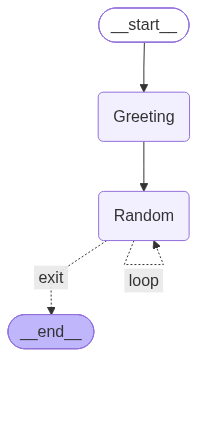

In [14]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
initial_state = { "name": "Guru", "numbers": [], "counter": 0 }
print(app.invoke(initial_state)) 

ENTER LOOP  1
ENTER LOOP  2
ENTER LOOP  3
ENTER LOOP  4
{'name': 'Hello Guru! Have a great day!', 'numbers': [6, 1, 7, 7, 0], 'counter': 5}


HIGHER OR LOWER NUMBER GAME

-Bounds set between 1 and 20, we choose a random number in that range
-Graph keeps guessing the number (max number of guesses is 7)
-Based on value node says higher or lower as per which next value is chosen

In [30]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END
import random

class AgentState(TypedDict):
    number:int
    counter:int
    found:bool
    upper_limit:int
    lower_limit:int
    output:str


In [36]:
def target(state:AgentState)->AgentState:
    """Sets a random number as target"""
    state['number']=random.randint(1,20)
    state['counter']=0
    state['lower_limit']=1
    state['upper_limit']=20
    return state

def continue_loop(state:AgentState)->str:
    """Decides whether or not we should continue looping"""
    if state['found']:
        return "leave_loop"
    
    if(state['counter']<7):
        print("Loop Count: ",state['counter'])
        return "loop"

    state['output']="Number not found"
    return "leave_loop"
    
        
def guess_number(state:AgentState)->AgentState:
    """Guess a random number between the limits and set new limit"""
    x=random.randint(state['lower_limit'],state['upper_limit'])
    state['counter']+=1
    if(x<state['number']):
        print(f"HIGHER THAN {x}")
        state['lower_limit']=x+1
    elif (x>state['number']):
        print(f"LOWER than {x}")
        state['upper_limit']=x-1 
    if x==state['number']:
        state['found']=True
        state['output']=f"Guessed the number {x} correctly in {state['counter']} guesses!!!"

    return state

In [37]:
graph=StateGraph(AgentState)

graph.add_node("CHOOSE_TARGET",target)
graph.add_node("GUESS",guess_number)
graph.add_edge(START,"CHOOSE_TARGET")
graph.add_edge("CHOOSE_TARGET","GUESS")

graph.add_conditional_edges(
    "GUESS",
    continue_loop,
    {
        "loop": "GUESS",
        "leave_loop": END
    }
)
app=graph.compile()


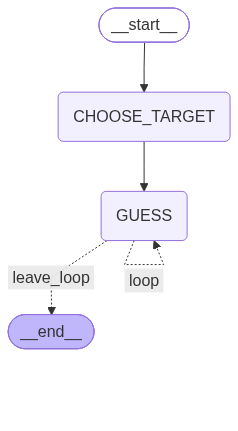

In [38]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [39]:
initial_state=AgentState(number=0,counter=0,found=False,upper_limit=0,lower_limit=0,output="")
print(app.invoke(initial_state))



LOWER than 18
Loop Count:  1
HIGHER THAN 1
Loop Count:  2
HIGHER THAN 6
Loop Count:  3
LOWER than 16
Loop Count:  4
LOWER than 10
Loop Count:  5
{'number': 8, 'counter': 6, 'found': True, 'upper_limit': 9, 'lower_limit': 7, 'output': 'Guessed the number 8 correctly in 6 guesses!!!'}
